# Instacart Refill Intelligence

**Dataset:** Instacart Market Basket Analysis (3.4M orders, 206K users, 50K products)

| Module | Focus | Key Question |
|--------|-------|--------------|
| 1. Replenishment Gap | Overdue refills | Which habitual products are late for reorder? |
| 2. Reorder Abandonment | Dropped products | Which regular items have users stopped buying? |
| 3. Basket Degradation | Shrinking baskets | Which users are losing department diversity? |

In [1]:
!pip install -q pandas numpy matplotlib seaborn kagglehub

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from insight_utils import data_profile, pareto_analysis, format_pct, InsightCollector, setup_plotting, top_bottom_items

collector = InsightCollector()
plt, sns = setup_plotting()
print('Imports ready.')

Imports ready.


In [3]:
import kagglehub
path = kagglehub.dataset_download('psparks/instacart-market-basket-analysis')
print(f'Dataset path: {path}')

# Find CSV files (handle subdirectory nesting)
import glob
csvs = glob.glob(os.path.join(path, '**', '*.csv'), recursive=True)
for f in sorted(csvs):
    print(f'  {os.path.basename(f)}')

Dataset path: C:\Users\benim\.cache\kagglehub\datasets\psparks\instacart-market-basket-analysis\versions\1
  aisles.csv
  departments.csv
  order_products__prior.csv
  order_products__train.csv
  orders.csv
  products.csv


In [4]:
# Load CSVs — build path helper
def find_csv(name):
    matches = [f for f in csvs if os.path.basename(f) == name]
    if matches:
        return matches[0]
    raise FileNotFoundError(f'{name} not found in {path}')

orders = pd.read_csv(find_csv('orders.csv'))
op_prior = pd.read_csv(find_csv('order_products__prior.csv'))
op_train = pd.read_csv(find_csv('order_products__train.csv'))
products = pd.read_csv(find_csv('products.csv'))
aisles = pd.read_csv(find_csv('aisles.csv'))
departments = pd.read_csv(find_csv('departments.csv'))

for name, df in [('orders', orders), ('op_prior', op_prior), ('op_train', op_train),
                  ('products', products), ('aisles', aisles), ('departments', departments)]:
    print(f'{name:25s} {str(df.shape):>15s}')

orders                       (3421083, 7)
op_prior                    (32434489, 4)
op_train                     (1384617, 4)
products                       (49688, 4)
aisles                           (134, 2)
departments                       (21, 2)


In [5]:
data_profile(orders)

,dtype,non_null,null_pct,nunique,sample
order_id,int64,3421083,0.0,3421083,2539329
user_id,int64,3421083,0.0,206209,1
eval_set,object,3421083,0.0,3,prior
order_number,int64,3421083,0.0,100,1
order_dow,int64,3421083,0.0,7,2
order_hour_of_day,int64,3421083,0.0,24,8
days_since_prior_order,float64,3214874,6.0,31,NaN


In [6]:
# Build master dataset: op_prior + orders + products + aisles + departments
# Selective columns and int32 dtypes to keep memory manageable

master = op_prior[['order_id', 'product_id', 'reordered', 'add_to_cart_order']].copy()
for col in ['order_id', 'product_id', 'reordered', 'add_to_cart_order']:
    master[col] = master[col].astype(np.int32)

# Merge orders (selective cols)
ord_cols = orders[['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']].copy()
ord_cols['order_id'] = ord_cols['order_id'].astype(np.int32)
ord_cols['user_id'] = ord_cols['user_id'].astype(np.int32)
ord_cols['order_number'] = ord_cols['order_number'].astype(np.int32)
ord_cols['days_since_prior_order'] = ord_cols['days_since_prior_order'].fillna(0).astype(np.int32)

master = master.merge(ord_cols, on='order_id', how='left')

# Merge products + aisles + departments
prod = products.merge(aisles, on='aisle_id').merge(departments, on='department_id')
prod_cols = prod[['product_id', 'product_name', 'aisle', 'department']].copy()
prod_cols['product_id'] = prod_cols['product_id'].astype(np.int32)

master = master.merge(prod_cols, on='product_id', how='left')

# Cap days_since_prior_order at 30
master['days_since_prior_order'] = master['days_since_prior_order'].clip(upper=30)

print(f'Master dataset: {master.shape}')
print(f'Memory: {master.memory_usage(deep=True).sum() / 1e9:.2f} GB')
master.head(3)

Master dataset: (32434489, 12)


Memory: 7.74 GB


,order_id,product_id,reordered,add_to_cart_order,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle,department
0,2,33120,1,1,202279,3,5,9,8,Organic Egg Whites,eggs,dairy eggs
1,2,28985,1,2,202279,3,5,9,8,Michigan Organic Kale,fresh vegetables,produce
2,2,9327,0,3,202279,3,5,9,8,Garlic Powder,spices seasonings,pantry


---
## Module 1: Replenishment Gap Intelligence
Identify habitual user-product pairs that are overdue for reorder.

In [7]:
# Identify habitual user-product pairs
# Criteria: ordered >= 3 times, reorder_rate >= 0.5

up = master.groupby(['user_id', 'product_id']).agg(
    times_ordered=('order_id', 'count'),
    reorder_sum=('reordered', 'sum'),
    product_name=('product_name', 'first'),
    department=('department', 'first'),
    aisle=('aisle', 'first')
).reset_index()

up['reorder_rate'] = up['reorder_sum'] / up['times_ordered']
habitual = up[(up['times_ordered'] >= 3) & (up['reorder_rate'] >= 0.5)].copy()

print(f'Total user-product pairs: {len(up):,}')
print(f'Habitual pairs (>=3 orders, >=50% reorder): {len(habitual):,}')
print(f'Unique users with habitual products: {habitual["user_id"].nunique():,}')
print(f'Unique habitual products: {habitual["product_id"].nunique():,}')

Total user-product pairs: 13,307,953
Habitual pairs (>=3 orders, >=50% reorder): 3,120,658
Unique users with habitual products: 183,828
Unique habitual products: 39,748


In [8]:
# Compute expected reorder interval per user-product (VECTORIZED)
# Use order_number gaps as temporal proxy since days_since_prior_order is capped at 30

# Get habitual pair keys for efficient merge
hab_keys = habitual[['user_id', 'product_id']].copy()

# Filter master to only habitual pairs via merge (much faster than isin on MultiIndex)
hab_orders = master[['user_id', 'product_id', 'order_number']].merge(
    hab_keys, on=['user_id', 'product_id'], how='inner'
).sort_values(['user_id', 'product_id', 'order_number'])

# Vectorized gap computation using shift within groups
hab_orders['prev_order_num'] = hab_orders.groupby(['user_id', 'product_id'])['order_number'].shift(1)
hab_orders['gap'] = hab_orders['order_number'] - hab_orders['prev_order_num']

# Compute median gap and last order per user-product pair
gap_stats = hab_orders.dropna(subset=['gap']).groupby(['user_id', 'product_id']).agg(
    median_gap_orders=('gap', 'median'),
    last_order_num=('order_number', 'max')
).reset_index()

# Also get last_order_num for pairs that may only have 1 row (no gap)
last_only = hab_orders.groupby(['user_id', 'product_id'])['order_number'].agg(['max', 'count']).reset_index()
last_only.columns = ['user_id', 'product_id', 'last_order_num', 'n_orders']
single_order_pairs = last_only[~last_only.set_index(['user_id', 'product_id']).index.isin(
    gap_stats.set_index(['user_id', 'product_id']).index
)]

# Get user's max order number
user_max_order = orders.groupby('user_id')['order_number'].max().reset_index()
user_max_order.columns = ['user_id', 'max_order_num']

gap_stats = gap_stats.merge(user_max_order, on='user_id')
gap_stats['orders_since_last'] = gap_stats['max_order_num'] - gap_stats['last_order_num']
gap_stats['expected_gap'] = gap_stats['median_gap_orders']

# Flag overdue: orders_since_last > expected_gap * 1.3
gap_stats['overdue'] = gap_stats['orders_since_last'] > (gap_stats['expected_gap'] * 1.3)
gap_stats['days_late_proxy'] = (gap_stats['orders_since_last'] - gap_stats['expected_gap']).clip(lower=0)

# Merge product info
gap_stats = gap_stats.merge(habitual[['user_id', 'product_id', 'product_name', 'department', 'aisle']], 
                            on=['user_id', 'product_id'], how='left')

overdue = gap_stats[gap_stats['overdue']].copy()
print(f'Overdue user-product pairs: {len(overdue):,}')
print(f'Users with overdue refills: {overdue["user_id"].nunique():,}')
print(f'Avg orders late: {overdue["days_late_proxy"].mean():.1f}')

Overdue user-product pairs: 1,591,355
Users with overdue refills: 148,138
Avg orders late: 9.9


Top 15 Overdue Products:


,product_name,department,users_overdue,avg_orders_late
2441,Banana,produce,17237,5.503394
22701,Organic Strawberries,produce,13642,9.196379
2293,Bag of Organic Bananas,produce,13575,5.808287
20178,Organic Baby Spinach,produce,11248,5.930610
21364,Organic Hass Avocado,produce,10871,8.196900
20146,Organic Avocado,produce,9223,9.710615
30546,Strawberries,produce,8224,7.213096
15662,Large Lemon,produce,7569,6.159797
16384,Limes,produce,7042,6.935246
22243,Organic Raspberries,produce,6622,8.134249


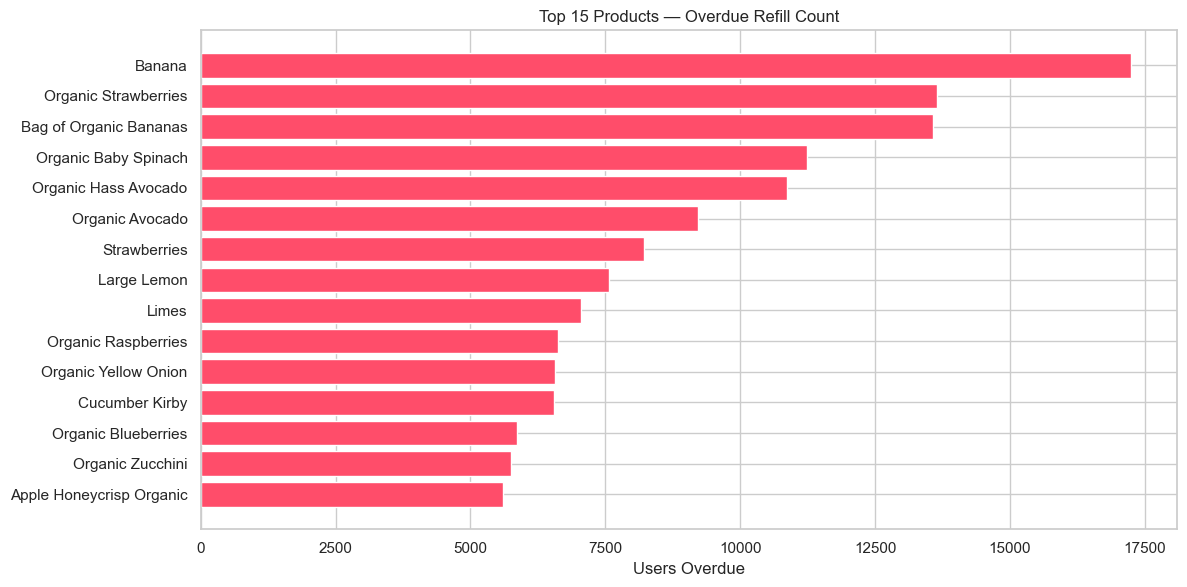

In [9]:
# Top 15 overdue products
top_overdue = overdue.groupby(['product_name', 'department']).agg(
    users_overdue=('user_id', 'nunique'),
    avg_orders_late=('days_late_proxy', 'mean')
).reset_index().sort_values('users_overdue', ascending=False).head(15)

print('Top 15 Overdue Products:')
display(top_overdue)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_overdue['product_name'].iloc[::-1], top_overdue['users_overdue'].iloc[::-1], color='#FF4D6A')
ax.set_xlabel('Users Overdue')
ax.set_title('Top 15 Products — Overdue Refill Count')
plt.tight_layout()
plt.show()

In [10]:
# Overdue by department
dept_overdue = overdue.groupby('department').agg(
    users_overdue=('user_id', 'nunique'),
    pairs_overdue=('product_id', 'count'),
    avg_orders_late=('days_late_proxy', 'mean')
).sort_values('users_overdue', ascending=False).reset_index()

print('Overdue by Department:')
display(dept_overdue.head(10))

top_dept = dept_overdue.iloc[0]
collector.add(
    'Replenishment Gap', 
    f'{top_dept["department"]} leads overdue refills',
    f'{top_dept["department"]} has {top_dept["users_overdue"]:,} users overdue across {top_dept["pairs_overdue"]:,} product pairs, '
    f'averaging {top_dept["avg_orders_late"]:.1f} orders late.',
    severity='risk'
)

Overdue by Department:


,department,users_overdue,pairs_overdue,avg_orders_late
0,produce,106018,497406,9.659514
1,dairy eggs,90748,266196,9.447651
2,beverages,62760,131635,9.614122
3,snacks,61397,155678,10.778655
4,frozen,53974,117006,10.101251
5,bakery,39275,59921,9.478522
6,deli,36482,56124,9.910805
7,pantry,33611,56422,10.832494
8,canned goods,29294,48469,9.539551
9,meat seafood,27456,38550,9.704436


Late Bucket Distribution:
  1-2 orders late     :  461,466 (29.0%)
  3-5 orders late     :  356,362 (22.4%)
  6-10 orders late    :  293,612 (18.5%)
  11+ orders late     :  479,915 (30.2%)


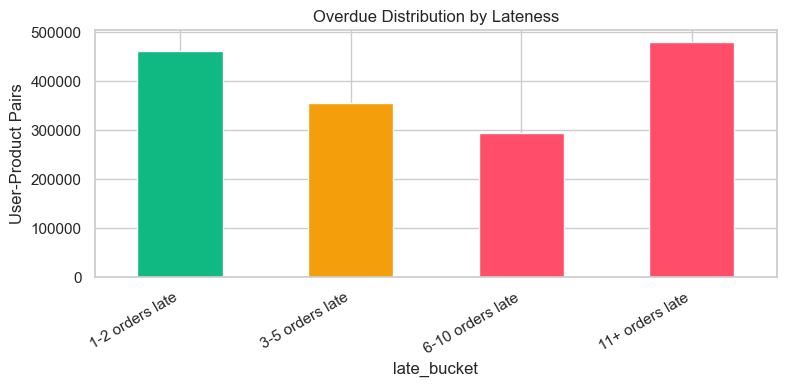

In [11]:
# Days-late bucket distribution (using orders-late as proxy)
# Buckets: 1-2 orders, 3-5, 6-10, 11+
def late_bucket(x):
    if x <= 2: return '1-2 orders late'
    elif x <= 5: return '3-5 orders late'
    elif x <= 10: return '6-10 orders late'
    else: return '11+ orders late'

overdue['late_bucket'] = overdue['days_late_proxy'].apply(late_bucket)
bucket_dist = overdue['late_bucket'].value_counts().reindex(
    ['1-2 orders late', '3-5 orders late', '6-10 orders late', '11+ orders late']
).fillna(0).astype(int)

print('Late Bucket Distribution:')
for bucket, count in bucket_dist.items():
    pct = count / len(overdue) * 100
    print(f'  {bucket:20s}: {count:>8,} ({pct:.1f}%)')

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#10B981', '#F59E0B', '#FF4D6A', '#FF4D6A']
bucket_dist.plot(kind='bar', ax=ax, color=colors)
ax.set_ylabel('User-Product Pairs')
ax.set_title('Overdue Distribution by Lateness')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Overdue Rate by Order Quantile:


,order_quantile,avg_max_order,overdue_rate,overdue_pairs
0,0,5.838272,26.0,53022
1,1,9.030532,40.2,93556
2,2,11.501980,44.9,71098
3,3,14.001669,47.6,111509
4,4,16.985428,49.6,107283
5,5,19.495646,51.1,67799
6,6,21.999348,52.3,99443
7,7,25.468838,53.2,118341
8,8,29.475191,54.2,106026
9,9,33.463349,55.1,96794


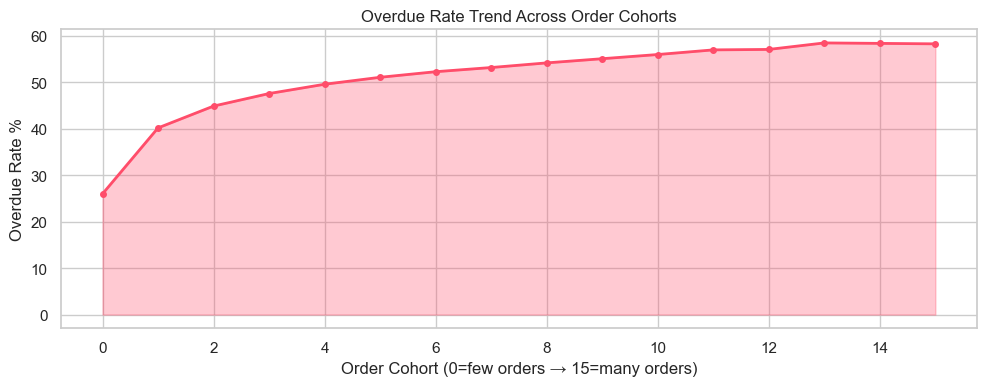

In [12]:
# Overdue trend over order-number quantiles (16 data points)
# Split users into 16 cohorts by their max order number, check overdue rate per cohort

gap_stats['order_quantile'] = pd.qcut(gap_stats['max_order_num'], 16, labels=False, duplicates='drop')

trend = gap_stats.groupby('order_quantile').agg(
    total_pairs=('user_id', 'count'),
    overdue_pairs=('overdue', 'sum'),
    avg_max_order=('max_order_num', 'mean')
).reset_index()
trend['overdue_rate'] = (trend['overdue_pairs'] / trend['total_pairs'] * 100).round(1)

print('Overdue Rate by Order Quantile:')
display(trend[['order_quantile', 'avg_max_order', 'overdue_rate', 'overdue_pairs']])

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(trend['order_quantile'], trend['overdue_rate'], alpha=0.3, color='#FF4D6A')
ax.plot(trend['order_quantile'], trend['overdue_rate'], color='#FF4D6A', linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Order Cohort (0=few orders → 15=many orders)')
ax.set_ylabel('Overdue Rate %')
ax.set_title('Overdue Rate Trend Across Order Cohorts')
plt.tight_layout()
plt.show()

# Save trend data for HTML
refill_trend_data = trend[['order_quantile', 'overdue_rate']].values.tolist()

---
## Module 2: Reorder Abandonment
Identify habitual products that users have stopped buying.

In [13]:
# Identify abandonment: habitual products absent from user's last 3 orders

# Get each user's last 3 prior order numbers
user_orders = orders[orders['eval_set'] == 'prior'][['user_id', 'order_id', 'order_number']].copy()
user_max = user_orders.groupby('user_id')['order_number'].max().reset_index()
user_max.columns = ['user_id', 'max_on']
user_orders = user_orders.merge(user_max, on='user_id')
last3_orders = user_orders[user_orders['order_number'] >= user_orders['max_on'] - 2]

# Products in last 3 orders per user — use merge instead of isin for speed
last3_prods = master[['user_id', 'product_id', 'order_id']].merge(
    last3_orders[['order_id']], on='order_id', how='inner'
)[['user_id', 'product_id']].drop_duplicates()

# Habitual products per user
hab_prods = habitual[['user_id', 'product_id']].copy()

# Find abandoned = habitual minus recent (anti-join)
# Mark recent products
last3_prods['in_recent'] = True
merged = hab_prods.merge(last3_prods, on=['user_id', 'product_id'], how='left')
abandoned = merged[merged['in_recent'].isna()][['user_id', 'product_id']].copy()

# Count abandoned per user
abandon_per_user = abandoned.groupby('user_id').size().reset_index(name='n_abandoned')
abandon = abandon_per_user[abandon_per_user['n_abandoned'] > 0]

# Product-level abandonment
abandon_exp = abandoned.merge(prod_cols, on='product_id', how='left')

print(f'Users with abandoned habitual products: {len(abandon):,}')
print(f'Total abandonment events: {len(abandon_exp):,}')

# Top 20 by abandonment count
top_abandon = abandon_exp.groupby(['product_name', 'department']).agg(
    abandonment_count=('user_id', 'count')
).reset_index().sort_values('abandonment_count', ascending=False).head(20)

print('\nTop 20 Abandoned Products:')
display(top_abandon)

Users with abandoned habitual products: 115,514
Total abandonment events: 1,509,187



Top 20 Abandoned Products:


,product_name,department,abandonment_count
22871,Organic Strawberries,produce,10998
2500,Banana,produce,10565
20331,Organic Baby Spinach,produce,9072
2353,Bag of Organic Bananas,produce,8799
21526,Organic Hass Avocado,produce,8715
16511,Limes,produce,7135
20299,Organic Avocado,produce,6888
30730,Strawberries,produce,6742
23409,Organic Yellow Onion,produce,6445
15775,Large Lemon,produce,6424


In [14]:
# Post-abandonment funnel
# Total abandoners → user still active (placed any order recently) → user inactive

total_abandoners = abandon['user_id'].nunique()

# Check if user has orders in the train set (their most recent order)
train_users = set(orders[orders['eval_set'] == 'train']['user_id'].unique())
abandon_users = set(abandon['user_id'])

# Users who returned (are in train set — they placed at least one more order)
returned = abandon_users.intersection(train_users)
never_returned = abandon_users - returned

print(f'=== Post-Abandonment Funnel ===')
print(f'Total users with abandoned products: {total_abandoners:,}')
print(f'Still active (placed subsequent order): {len(returned):,} ({len(returned)/total_abandoners*100:.1f}%)')
print(f'Never returned: {len(never_returned):,} ({len(never_returned)/total_abandoners*100:.1f}%)')

collector.add(
    'Reorder Abandonment',
    f'{len(never_returned):,} users permanently lost after product abandonment',
    f'Of {total_abandoners:,} users who abandoned habitual products, '
    f'{len(never_returned):,} ({len(never_returned)/total_abandoners*100:.1f}%) never placed another order. '
    f'This represents a permanent loss of habitual buyers.',
    severity='risk'
)

=== Post-Abandonment Funnel ===
Total users with abandoned products: 115,514
Still active (placed subsequent order): 73,410 (63.6%)
Never returned: 42,104 (36.4%)


In [15]:
# Abandonment rate by department
dept_abandon = abandon_exp.groupby('department').agg(
    abandonment_count=('user_id', 'count'),
    users_affected=('user_id', 'nunique')
).reset_index().sort_values('abandonment_count', ascending=False)

# Total habitual pairs by department for rate calculation
dept_total = habitual.groupby('department')['user_id'].count().reset_index()
dept_total.columns = ['department', 'total_habitual']
dept_abandon = dept_abandon.merge(dept_total, on='department', how='left')
dept_abandon['abandon_rate'] = (dept_abandon['abandonment_count'] / dept_abandon['total_habitual'] * 100).round(1)

print('Abandonment by Department:')
display(dept_abandon.head(10))

top_dept_ab = dept_abandon.iloc[0]
collector.add(
    'Reorder Abandonment',
    f'{top_dept_ab["department"]} has highest abandonment volume',
    f'{top_dept_ab["department"]} department: {int(top_dept_ab["abandonment_count"]):,} abandonment events '
    f'affecting {int(top_dept_ab["users_affected"]):,} users ({top_dept_ab["abandon_rate"]:.1f}% rate).',
    severity='warning'
)

Abandonment by Department:


,department,abandonment_count,users_affected,total_habitual,abandon_rate
0,produce,456895,84416,987990,46.2
1,dairy eggs,238991,72367,534362,44.7
2,snacks,146518,52485,282385,51.9
3,beverages,112383,49977,258902,43.4
4,frozen,108921,46230,215606,50.5
5,pantry,74018,35197,125534,59.0
6,bakery,54027,33051,116099,46.5
7,canned goods,52006,27895,94080,55.3
8,deli,51357,31524,105762,48.6
9,dry goods pasta,42535,24554,77574,54.8


Abandonment Rate by Order Cohort:


,cohort,total_users,abandon_users,abandon_rate
0,0,26302,12648,48.1
1,1,13668,12374,90.5
2,2,12586,5845,46.4
3,3,11120,10722,96.4
4,4,18685,9282,49.7
5,5,14628,7708,52.7
6,6,11802,9348,79.2
7,7,13897,9669,69.6
8,8,16039,10264,64.0
9,9,15918,8898,55.9


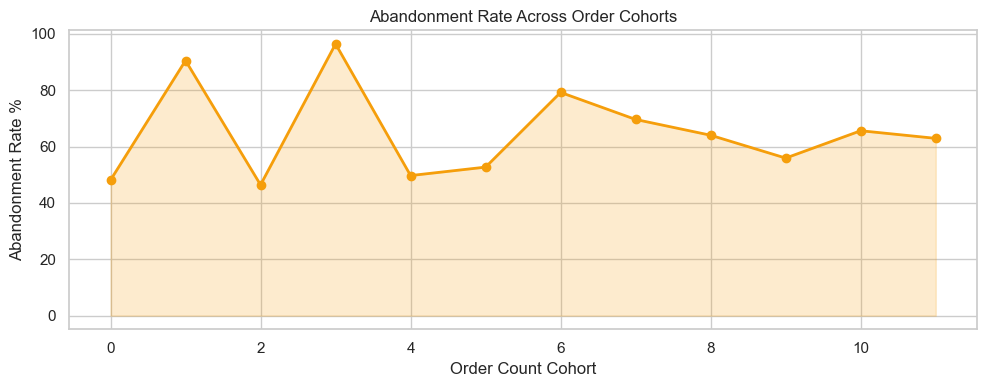

In [16]:
# Abandonment trend over order sequence cohorts
# Group users by their total order count, compute abandonment rate per cohort

user_order_counts = orders.groupby('user_id')['order_number'].max().reset_index()
user_order_counts.columns = ['user_id', 'total_orders']

abandon_with_orders = abandon[['user_id', 'n_abandoned']].merge(user_order_counts, on='user_id')
hab_user_ids = habitual[['user_id']].drop_duplicates()
hab_with_orders = hab_user_ids.merge(user_order_counts, on='user_id')

# Create 12 cohorts by total orders
hab_with_orders['cohort'] = pd.qcut(hab_with_orders['total_orders'], 12, labels=False, duplicates='drop')
abandon_with_orders['cohort'] = pd.qcut(abandon_with_orders['total_orders'], 12, labels=False, duplicates='drop')

cohort_total = hab_with_orders.groupby('cohort')['user_id'].nunique().reset_index()
cohort_total.columns = ['cohort', 'total_users']
cohort_abandon = abandon_with_orders.groupby('cohort')['user_id'].nunique().reset_index()
cohort_abandon.columns = ['cohort', 'abandon_users']

cohort_trend = cohort_total.merge(cohort_abandon, on='cohort', how='left').fillna(0)
cohort_trend['abandon_rate'] = (cohort_trend['abandon_users'] / cohort_trend['total_users'] * 100).round(1)

print('Abandonment Rate by Order Cohort:')
display(cohort_trend)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cohort_trend['cohort'], cohort_trend['abandon_rate'], color='#F59E0B', linewidth=2, marker='o')
ax.fill_between(cohort_trend['cohort'], cohort_trend['abandon_rate'], alpha=0.2, color='#F59E0B')
ax.set_xlabel('Order Count Cohort')
ax.set_ylabel('Abandonment Rate %')
ax.set_title('Abandonment Rate Across Order Cohorts')
plt.tight_layout()
plt.show()

abandon_trend_data = cohort_trend[['cohort', 'abandon_rate']].values.tolist()

---
## Module 3: Basket Degradation
Track users whose basket breadth (department diversity) is shrinking over time.

In [17]:
# Department count per user per order (basket_breadth)
basket_breadth = master.groupby(['user_id', 'order_id', 'order_number'])['department'].nunique().reset_index()
basket_breadth.columns = ['user_id', 'order_id', 'order_number', 'dept_count']

print(f'Orders with breadth computed: {len(basket_breadth):,}')
print(f'Avg department count per order: {basket_breadth["dept_count"].mean():.2f}')
print(f'Median: {basket_breadth["dept_count"].median():.0f}')

Orders with breadth computed: 3,214,874
Avg department count per order: 4.74
Median: 4


In [18]:
# Flag degrading users: 5+ orders, last-third breadth < first-third by 2+ departments
# VECTORIZED approach — no groupby().apply()

bb = basket_breadth.sort_values(['user_id', 'order_number']).copy()

# Count orders per user and filter to 5+
user_counts = bb.groupby('user_id').size().reset_index(name='n_orders')
users_5plus_ids = user_counts[user_counts['n_orders'] >= 5]['user_id']
bb5 = bb[bb['user_id'].isin(users_5plus_ids)].copy()

# Rank each order within user (0-indexed)
bb5['rank'] = bb5.groupby('user_id').cumcount()
bb5 = bb5.merge(user_counts, on='user_id')
bb5['third'] = bb5['n_orders'] // 3

# First third: rank < third, Last third: rank >= n_orders - third
bb5['is_first'] = bb5['rank'] < bb5['third']
bb5['is_last'] = bb5['rank'] >= (bb5['n_orders'] - bb5['third'])

first_avg = bb5[bb5['is_first']].groupby('user_id')['dept_count'].mean().reset_index()
first_avg.columns = ['user_id', 'first_avg']
last_avg = bb5[bb5['is_last']].groupby('user_id')['dept_count'].mean().reset_index()
last_avg.columns = ['user_id', 'last_avg']

degradation = first_avg.merge(last_avg, on='user_id').merge(user_counts, on='user_id')
degradation['first_avg'] = degradation['first_avg'].round(1)
degradation['last_avg'] = degradation['last_avg'].round(1)
degradation['drop'] = (degradation['first_avg'] - degradation['last_avg']).round(1)
degradation['total_orders'] = degradation['n_orders']
degradation['degrading'] = degradation['drop'] >= 2

degrading_users = degradation[degradation['degrading']].copy()

total_eligible = len(degradation)
n_degrading = len(degrading_users)

print(f'Users with 5+ orders: {total_eligible:,}')
print(f'Actively degrading: {n_degrading:,} ({n_degrading/total_eligible*100:.1f}%)')
print(f'Avg dept drop: {degrading_users["drop"].mean():.1f}')
print(f'Avg first-third breadth: {degrading_users["first_avg"].mean():.1f}')
print(f'Avg last-third breadth: {degrading_users["last_avg"].mean():.1f}')

collector.add(
    'Basket Degradation',
    f'{n_degrading:,} users actively losing basket breadth',
    f'{n_degrading:,} users ({n_degrading/total_eligible*100:.1f}%) show department diversity dropping by 2+ '
    f'categories. Average breadth went from {degrading_users["first_avg"].mean():.1f} to {degrading_users["last_avg"].mean():.1f} departments.',
    severity='warning'
)

Users with 5+ orders: 162,633
Actively degrading: 17,632 (10.8%)
Avg dept drop: 2.9
Avg first-third breadth: 6.8
Avg last-third breadth: 3.9


In [19]:
# 3-5 real basket trail examples (early → late departments)
# Reuse dept_compare from next cell, but compute for sample users here

sample_users = degrading_users.sort_values('drop', ascending=False).head(5)['user_id'].values

for uid in sample_users[:3]:
    user_data = master[master['user_id'] == uid].sort_values('order_number')
    order_nums = sorted(user_data['order_number'].unique())
    n = len(order_nums)
    third = n // 3
    
    early_depts = set(user_data[user_data['order_number'].isin(order_nums[:third])]['department'].unique())
    late_depts = set(user_data[user_data['order_number'].isin(order_nums[-third:])]['department'].unique())
    dropped = early_depts - late_depts
    
    info = degradation[degradation['user_id'] == uid].iloc[0]
    print(f'\nUser {uid} — {int(info["total_orders"])} orders')
    print(f'  Early departments ({len(early_depts)}): {", ".join(sorted(early_depts))}')
    print(f'  Late departments  ({len(late_depts)}): {", ".join(sorted(late_depts))}')
    print(f'  Dropped: {", ".join(sorted(dropped)) if dropped else "(narrowing within same depts)"}')
    print(f'  Breadth: {info["first_avg"]} → {info["last_avg"]} (drop: {info["drop"]})')


User 50635 — 5 orders
  Early departments (14): bakery, beverages, breakfast, canned goods, dairy eggs, deli, dry goods pasta, frozen, household, international, meat seafood, pantry, produce, snacks
  Late departments  (1): produce
  Dropped: bakery, beverages, breakfast, canned goods, dairy eggs, deli, dry goods pasta, frozen, household, international, meat seafood, pantry, snacks
  Breadth: 14.0 → 1.0 (drop: 13.0)

User 43696 — 6 orders
  Early departments (14): babies, bakery, beverages, canned goods, dairy eggs, deli, dry goods pasta, frozen, household, meat seafood, missing, pantry, produce, snacks
  Late departments  (3): dairy eggs, deli, produce
  Dropped: babies, bakery, beverages, canned goods, dry goods pasta, frozen, household, meat seafood, missing, pantry, snacks
  Breadth: 12.5 → 1.5 (drop: 11.0)

User 155771 — 5 orders
  Early departments (12): bakery, beverages, breakfast, canned goods, dairy eggs, dry goods pasta, frozen, household, personal care, pets, produce, snac

Department Drop Rates (which disappear first):


,department,drop_count,drop_rate
16,pantry,5715,32.4
6,canned goods,5443,30.9
9,dry goods pasta,5322,30.2
2,bakery,5299,30.1
8,deli,5293,30.0
20,snacks,5153,29.2
10,frozen,5087,28.9
4,breakfast,4800,27.2
13,meat seafood,4644,26.3
3,beverages,4210,23.9


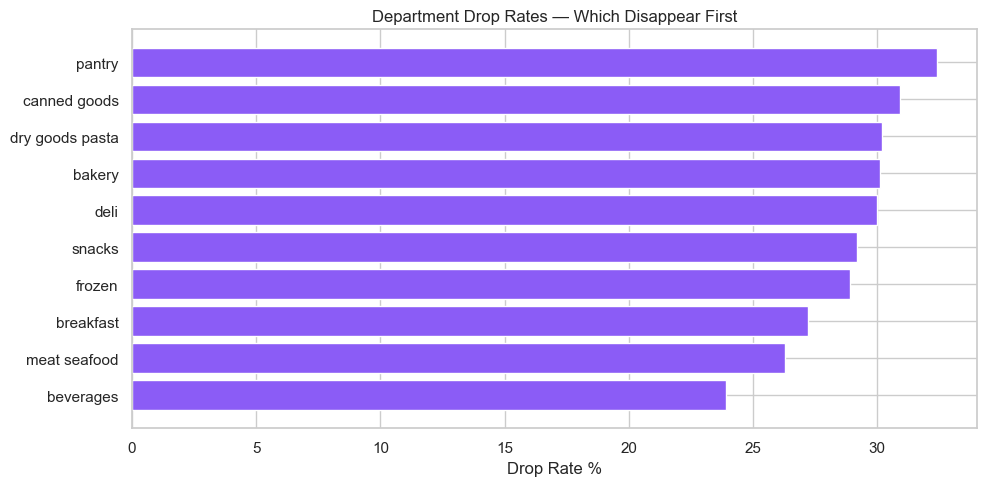

In [20]:
# Department drop rates — which departments disappear first (VECTORIZED)

# For degrading users, find departments in early orders vs late orders
deg_ids = degrading_users['user_id'].values
deg_master = master[master['user_id'].isin(deg_ids)][['user_id', 'order_number', 'department']].copy()

# Add order rank and user order count
deg_bb = basket_breadth[basket_breadth['user_id'].isin(deg_ids)].sort_values(['user_id', 'order_number'])
deg_bb['rank'] = deg_bb.groupby('user_id').cumcount()
deg_bb = deg_bb.merge(user_counts[user_counts['user_id'].isin(deg_ids)], on='user_id')
deg_bb['third'] = deg_bb['n_orders'] // 3

# Map order_number to early/late phase
early_map = deg_bb[deg_bb['rank'] < deg_bb['third']][['user_id', 'order_number']].copy()
early_map['phase'] = 'early'
late_map = deg_bb[deg_bb['rank'] >= (deg_bb['n_orders'] - deg_bb['third'])][['user_id', 'order_number']].copy()
late_map['phase'] = 'late'

# Early departments per user
early_depts = deg_master.merge(early_map, on=['user_id', 'order_number']).groupby('user_id')['department'].apply(set).reset_index()
early_depts.columns = ['user_id', 'early_depts']

# Late departments per user
late_depts = deg_master.merge(late_map, on=['user_id', 'order_number']).groupby('user_id')['department'].apply(set).reset_index()
late_depts.columns = ['user_id', 'late_depts']

dept_compare = early_depts.merge(late_depts, on='user_id', how='left')
dept_compare['late_depts'] = dept_compare['late_depts'].apply(lambda x: x if isinstance(x, set) else set())
dept_compare['dropped'] = dept_compare.apply(lambda r: r['early_depts'] - r['late_depts'], axis=1)

# Explode dropped departments
drop_exp = dept_compare[['user_id', 'dropped']].explode('dropped').dropna(subset=['dropped'])
drop_exp.columns = ['user_id', 'department']

dept_drop_rates = drop_exp.groupby('department')['user_id'].count().reset_index()
dept_drop_rates.columns = ['department', 'drop_count']
dept_drop_rates['drop_rate'] = (dept_drop_rates['drop_count'] / n_degrading * 100).round(1)
dept_drop_rates = dept_drop_rates.sort_values('drop_rate', ascending=False)

print('Department Drop Rates (which disappear first):')
display(dept_drop_rates.head(10))

fig, ax = plt.subplots(figsize=(10, 5))
top10 = dept_drop_rates.head(10)
ax.barh(top10['department'].iloc[::-1], top10['drop_rate'].iloc[::-1], color='#8B5CF6')
ax.set_xlabel('Drop Rate %')
ax.set_title('Department Drop Rates — Which Disappear First')
plt.tight_layout()
plt.show()

In [21]:
# Time-to-churn: orders from first breadth shrink to last order (VECTORIZED)
# For degrading users, find first order where dept_count < early_avg - 1

deg_bb2 = basket_breadth[basket_breadth['user_id'].isin(deg_ids)].sort_values(['user_id', 'order_number']).copy()
deg_bb2 = deg_bb2.merge(degrading_users[['user_id', 'first_avg']], on='user_id')
deg_bb2['threshold'] = deg_bb2['first_avg'] - 1
deg_bb2['below'] = deg_bb2['dept_count'] < deg_bb2['threshold']

# First order below threshold per user
first_shrink = deg_bb2[deg_bb2['below']].groupby('user_id')['order_number'].min().reset_index()
first_shrink.columns = ['user_id', 'first_shrink_order']

# Last order per user
last_order = deg_bb2.groupby('user_id')['order_number'].max().reset_index()
last_order.columns = ['user_id', 'last_order']

churn_df = first_shrink.merge(last_order, on='user_id')
churn_df['distance'] = churn_df['last_order'] - churn_df['first_shrink_order']
churn_dist = churn_df['distance']

print(f'Time-to-churn stats (orders from first shrink to last order):')
print(f'  Median: {churn_dist.median():.0f} orders')
print(f'  Mean: {churn_dist.mean():.1f} orders')
print(f'  25th percentile: {churn_dist.quantile(0.25):.0f} orders')
print(f'  75th percentile: {churn_dist.quantile(0.75):.0f} orders')

# Survival curve data
survival_points = []
for pct in np.arange(0, 105, 5):
    if pct == 0:
        survival_points.append((0, 100))
    else:
        val = np.percentile(churn_dist, pct) if pct <= 100 else churn_dist.max()
        remaining = 100 - pct
        survival_points.append((val, remaining))

print('\nSurvival curve (orders → % still active):')
for orders_val, pct_remaining in survival_points[:6]:
    print(f'  After {orders_val:.0f} orders: {pct_remaining:.0f}% still active')

collector.add(
    'Basket Degradation',
    f'Median {churn_dist.median():.0f} orders from first shrink to last purchase',
    f'Once basket breadth starts declining, degrading users have a median window of '
    f'{churn_dist.median():.0f} orders before their last purchase. '
    f'This is the intervention window.',
    severity='opportunity'
)

Time-to-churn stats (orders from first shrink to last order):
  Median: 5 orders
  Mean: 8.4 orders
  25th percentile: 3 orders
  75th percentile: 10 orders

Survival curve (orders → % still active):
  After 0 orders: 100% still active
  After 1 orders: 95% still active
  After 1 orders: 90% still active
  After 2 orders: 85% still active
  After 3 orders: 80% still active
  After 3 orders: 75% still active


In [22]:
# Degradation score by department — which departments are most associated with degrading users

# Department frequency in degrading users' early baskets
degrading_ids = set(degrading_users['user_id'])
deg_data = master[master['user_id'].isin(degrading_ids)]

dept_scores = deg_data.groupby('department').agg(
    users=('user_id', 'nunique'),
    orders=('order_id', 'nunique')
).reset_index()
dept_scores['score'] = (dept_scores['users'] / n_degrading * 100).round(1)
dept_scores = dept_scores.sort_values('score', ascending=False)

print('Degradation Score by Department (% of degrading users who buy from dept):')
display(dept_scores.head(10))

collector.add(
    'Basket Degradation',
    f'Top department at risk: {dept_scores.iloc[0]["department"]}',
    f'{dept_scores.iloc[0]["department"]} appears in {dept_scores.iloc[0]["score"]}% of degrading users\' baskets. '
    f'Combined with high drop rates, this signals migration to competing channels.',
    severity='risk'
)

Degradation Score by Department (% of degrading users who buy from dept):


,department,users,orders,score
7,dairy eggs,17215,145263,97.6
19,produce,17185,156045,97.5
16,pantry,16060,81579,91.1
20,snacks,15935,95127,90.4
3,beverages,15608,99312,88.5
10,frozen,15469,89271,87.7
2,bakery,13740,66585,77.9
6,canned goods,13139,53104,74.5
8,deli,13016,57977,73.8
9,dry goods pasta,12579,48621,71.3


---
## Summary — Dashboard Values

In [23]:
# ====================================================================
# PRINT ALL DASHBOARD VALUES
# ====================================================================

total_users = orders['user_id'].nunique()
total_orders = orders['order_id'].nunique()
total_products = products['product_id'].nunique()

print('=' * 70)
print('DASHBOARD VALUES')
print('=' * 70)

print(f'\n--- HEADER ---')
print(f'Total users: {total_users:,}')
print(f'Total orders: {total_orders:,}')
print(f'Total products: {total_products:,}')

print(f'\n--- MODULE 1: REPLENISHMENT GAP ---')
print(f'Users overdue: {overdue["user_id"].nunique():,}')
print(f'Overdue pairs: {len(overdue):,}')
print(f'Avg orders late: {overdue["days_late_proxy"].mean():.1f}')
recoverable_pct = bucket_dist.iloc[:2].sum() / len(overdue) * 100
print(f'Recoverable (1-5 orders late): {recoverable_pct:.0f}%')
print(f'\nTop overdue products:')
for _, row in top_overdue.head(12).iterrows():
    print(f'  {row["product_name"]:40s} | {row["department"]:15s} | {int(row["users_overdue"]):>5} users | {row["avg_orders_late"]:.1f} orders late')
print(f'\nDepartment overdue:')
for _, row in dept_overdue.head(10).iterrows():
    print(f'  {row["department"]:20s} | {int(row["users_overdue"]):>6} users | {row["avg_orders_late"]:.1f} avg late')
print(f'\nLate buckets:')
for bucket, count in bucket_dist.items():
    print(f'  {bucket:20s}: {count:>8,} ({count/len(overdue)*100:.1f}%)')
print(f'\nTrend data (16 points):')
for q, rate in refill_trend_data:
    print(f'  Q{int(q):02d}: {rate}%')

print(f'\n--- MODULE 2: REORDER ABANDONMENT ---')
print(f'Abandonment events: {len(abandon_exp):,}')
print(f'Users affected: {total_abandoners:,}')
print(f'Permanent loss rate: {len(never_returned)/total_abandoners*100:.1f}%')
est_orders_lost = len(never_returned) * 3  # conservative estimate
print(f'Est. orders lost: {est_orders_lost:,}')
print(f'\nFunnel:')
print(f'  Total abandoners: {total_abandoners:,}')
print(f'  Returned: {len(returned):,} ({len(returned)/total_abandoners*100:.1f}%)')
print(f'  Never returned: {len(never_returned):,} ({len(never_returned)/total_abandoners*100:.1f}%)')
print(f'\nTop abandoned products:')
for _, row in top_abandon.head(10).iterrows():
    print(f'  {row["product_name"]:40s} | {row["department"]:15s} | {int(row["abandonment_count"]):>5} abandonments')
print(f'\nDepartment abandonment:')
for _, row in dept_abandon.head(10).iterrows():
    print(f'  {row["department"]:20s} | {int(row["abandonment_count"]):>6} events | {row["abandon_rate"]:.1f}% rate')
print(f'\nAbandon trend data:')
for c, rate in abandon_trend_data:
    print(f'  C{int(c):02d}: {rate}%')

print(f'\n--- MODULE 3: BASKET DEGRADATION ---')
print(f'Actively degrading: {n_degrading:,}')
print(f'Median orders to churn: {churn_dist.median():.0f}')
print(f'Depts at risk: {len(dept_drop_rates[dept_drop_rates["drop_rate"] > 5]):,}')
print(f'Intervention window: ~{churn_dist.quantile(0.25):.0f}-{churn_dist.quantile(0.75):.0f} orders')
print(f'\nDepartment drop rates:')
for _, row in dept_drop_rates.head(10).iterrows():
    print(f'  {row["department"]:20s} | {row["drop_rate"]:>5.1f}%')
print(f'\nDegradation scores:')
for _, row in dept_scores.head(10).iterrows():
    print(f'  {row["department"]:20s} | {row["score"]:>5.1f}%')
print(f'\nSurvival curve:')
for orders_val, pct_remaining in survival_points:
    print(f'  {orders_val:.0f} orders → {pct_remaining:.0f}% still active')
print(f'\nBasket trail examples:')
for uid in sample_users[:3]:
    user_data = master[master['user_id'] == uid].sort_values('order_number')
    order_nums = sorted(user_data['order_number'].unique())
    n = len(order_nums)
    third = n // 3
    early_depts = sorted(user_data[user_data['order_number'].isin(order_nums[:third])]['department'].unique())
    late_depts = sorted(user_data[user_data['order_number'].isin(order_nums[-third:])]['department'].unique())
    dropped = sorted(set(early_depts) - set(late_depts))
    info = degradation[degradation['user_id'] == uid].iloc[0]
    print(f'  User {uid}: early={early_depts} → late={late_depts} | dropped={dropped} | {info["first_avg"]}→{info["last_avg"]}')

DASHBOARD VALUES

--- HEADER ---
Total users: 206,209
Total orders: 3,421,083
Total products: 49,688

--- MODULE 1: REPLENISHMENT GAP ---
Users overdue: 148,138
Overdue pairs: 1,591,355
Avg orders late: 9.9
Recoverable (1-5 orders late): 51%

Top overdue products:
  Banana                                   | produce         | 17237 users | 5.5 orders late
  Organic Strawberries                     | produce         | 13642 users | 9.2 orders late
  Bag of Organic Bananas                   | produce         | 13575 users | 5.8 orders late
  Organic Baby Spinach                     | produce         | 11248 users | 5.9 orders late
  Organic Hass Avocado                     | produce         | 10871 users | 8.2 orders late
  Organic Avocado                          | produce         |  9223 users | 9.7 orders late
  Strawberries                             | produce         |  8224 users | 7.2 orders late
  Large Lemon                              | produce         |  7569 users | 6.2 ord

In [24]:
# Additional insights
collector.add(
    'Replenishment Gap',
    f'{overdue["user_id"].nunique():,} users with overdue habitual refills',
    f'{overdue["user_id"].nunique():,} users have at least one habitual product overdue. '
    f'{recoverable_pct:.0f}% are only 1-5 orders late — recoverable with a simple nudge.',
    severity='opportunity'
)

collector.add(
    'Replenishment Gap',
    'Late bucket concentration in early stages',
    f'{bucket_dist.iloc[0]:,} user-product pairs are only 1-2 orders late. '
    f'Early intervention here has the highest ROI before lateness compounds.',
    severity='opportunity'
)

collector.add(
    'Reorder Abandonment',
    f'Top abandoned product: {top_abandon.iloc[0]["product_name"]}',
    f'{top_abandon.iloc[0]["product_name"]} has {int(top_abandon.iloc[0]["abandonment_count"]):,} abandonment events — '
    f'the highest of any product. This is a key target for retention campaigns.',
    severity='risk'
)

collector.add(
    'Basket Degradation',
    f'{dept_drop_rates.iloc[0]["department"]} drops first from degrading baskets',
    f'{dept_drop_rates.iloc[0]["department"]} has a {dept_drop_rates.iloc[0]["drop_rate"]}% drop rate — '
    f'the first department users cut when their baskets start shrinking.',
    severity='warning'
)

collector.add(
    'Cross-Module',
    'Combined revenue risk from all three signals',
    f'Overdue refills ({overdue["user_id"].nunique():,} users) + abandonment ({total_abandoners:,} users) + '
    f'degradation ({n_degrading:,} users) represent overlapping but distinct churn signals. '
    f'Addressing all three in sequence maximizes retention impact.',
    severity='risk'
)

print(collector.summary())

INSIGHT SUMMARY

--- REPLENISHMENT GAP ---
  [RISK] produce leads overdue refills
     produce has 106,018 users overdue across 497,406 product pairs, averaging 9.7 orders late.
  [OPPORTUNITY] 148,138 users with overdue habitual refills
     148,138 users have at least one habitual product overdue. 51% are only 1-5 orders late — recoverable with a simple nudge.
  [OPPORTUNITY] Late bucket concentration in early stages
     461,466 user-product pairs are only 1-2 orders late. Early intervention here has the highest ROI before lateness compounds.

--- REORDER ABANDONMENT ---
  [RISK] 42,104 users permanently lost after product abandonment
     Of 115,514 users who abandoned habitual products, 42,104 (36.4%) never placed another order. This represents a permanent loss of habitual buyers.
  [WARNING] produce has highest abandonment volume
     produce department: 456,895 abandonment events affecting 84,416 users (46.2% rate).
  [RISK] Top abandoned product: Organic Strawberries
     Organ